In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kktk

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

/rfs/project/rfs-iCNyzSAaucw/kk837/github/kktk/kktk/plotting.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=80)

# Function

In [4]:
# https://cell2location.readthedocs.io/en/latest/notebooks/cell2location_short_demo.html
def select_slide(adata, s, s_col='sample'):
    r""" This function selects the data for one slide from the spatial anndata object.

    :param adata: Anndata object with multiple spatial experiments
    :param s: name of selected experiment
    :param s_col: column in adata.obs listing experiment name for each location
    """

    slide = adata[adata.obs[s_col].isin([s]), :]
    s_keys = list(slide.uns['spatial'].keys())
    s_spatial = np.array(s_keys)[[s in k for k in s_keys]][0]

    slide.uns['spatial'] = {s_spatial: slide.uns['spatial'][s_spatial]}

    return slide

# Variables

In [5]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'
celltype = 'EpicardialCells'

In [ ]:
# figdir = '/nfs/team205/heart/fetal_ms_figures/raw_plots_kk/Aug2024'
# table_dir = '/nfs/team205/heart/fetal_ms_figures/tables/Aug2024'

In [6]:
!ls -ls {data_object_dir}

total 2323648
233856 -rwxrwx---+ 1 kk837 kk837  495041445 Jan 28 08:54 b2c_cells_AtrialCardiomyocytes_lognorm.h5ad
 46424 -rwxrwx---+ 1 kk837 kk837   79748134 Jan 29 06:55 b2c_cells_EndothelialCells_lognorm.h5ad
 27984 -rwxrwx---+ 1 kk837 kk837   58503701 Jan  2 14:57 b2c_cells_EndothelialCells_raw.h5ad
 22120 -rwxrwx---+ 1 kk837 kk837   43772600 Jan  2 14:57 b2c_cells_EpicardialCells_raw.h5ad
 17456 -rwxrwx---+ 1 kk837 kk837   33218222 Jan  2 14:57 b2c_cells_LymphoidCells_raw.h5ad
324488 -rwxrwx---+ 1 kk837 kk837  697382266 Jan 29 04:26 b2c_cells_MesenchymalCells_lognorm.h5ad
281688 -rwxrwx---+ 1 kk837 kk837  658626360 Jan  2 14:57 b2c_cells_MesenchymalCells_raw.h5ad
 33048 -rwxrwx---+ 1 kk837 kk837   54512113 Jan 29 00:36 b2c_cells_MyeloidCells_lognorm.h5ad
 19560 -rwxrwx---+ 1 kk837 kk837   38611189 Jan  2 14:57 b2c_cells_MyeloidCells_raw.h5ad
 43024 -rwxrwx---+ 1 kk837 kk837   73958670 Jan 29 04:53 b2c_cells_NeuralCells_lognorm.h5ad
 26720 -rwxrwx---+ 1 kk837 kk837   55166577 Jan  

# Read in data

In [7]:
# read in
adata = sc.read_h5ad(f'{data_object_dir}/b2c_cells_{celltype}_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 2399 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_tacco_ref-hd-scn_colors', 'donor_colors', 'library_colors', 'neighbors', 'umap'

# Log-normalisation

In [8]:
sc.pp.filter_genes(adata, min_cells=3)
print(adata.shape)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(adata.X.data[:5])

(2399, 13773)
[2.58097504 2.58097504 2.58097504 2.58097504 2.58097504]


# Read in scVI-latent space and clustering results

In [9]:
adata_latent = sc.read_h5ad(f'{data_object_dir}/scVI/latent_variables/b2c_cells_{celltype}_correcting-donor_n-layers-3.h5ad')
adata_latent

AnnData object with n_obs × n_vars = 2399 × 50
    obs: 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0'
    uns: 'neighbors', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [10]:
adata.obsm['X_scVI'] = adata_latent[adata.obs_names,:].X.copy()
adata.obsm['X_umap'] = adata_latent[adata.obs_names,:].obsm['X_umap'].copy()
adata.obs[adata_latent.obs.columns] = adata_latent[adata.obs_names,:].obs.copy()

In [11]:
adata

AnnData object with n_obs × n_vars = 2399 × 13773
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'scVI_leiden_0.2', 'scVI_leiden_0.3', 'scVI_leiden_0.4', 'scVI_leiden_0.5', 'scVI_leiden_0.8', 'scVI_leiden_1.0', 'scVI_leiden_1.5', 'scVI_leiden_2.0', 'scVI_leiden_3.0', 'scVI_leiden_4.0'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_c

In [12]:
adata.obs['library'].value_counts()

library
HEA_FOET14880396                       1316
CellTalkHHD_Human_13_BRC2757-2758-7    1083
Name: count, dtype: int64

# Plotting

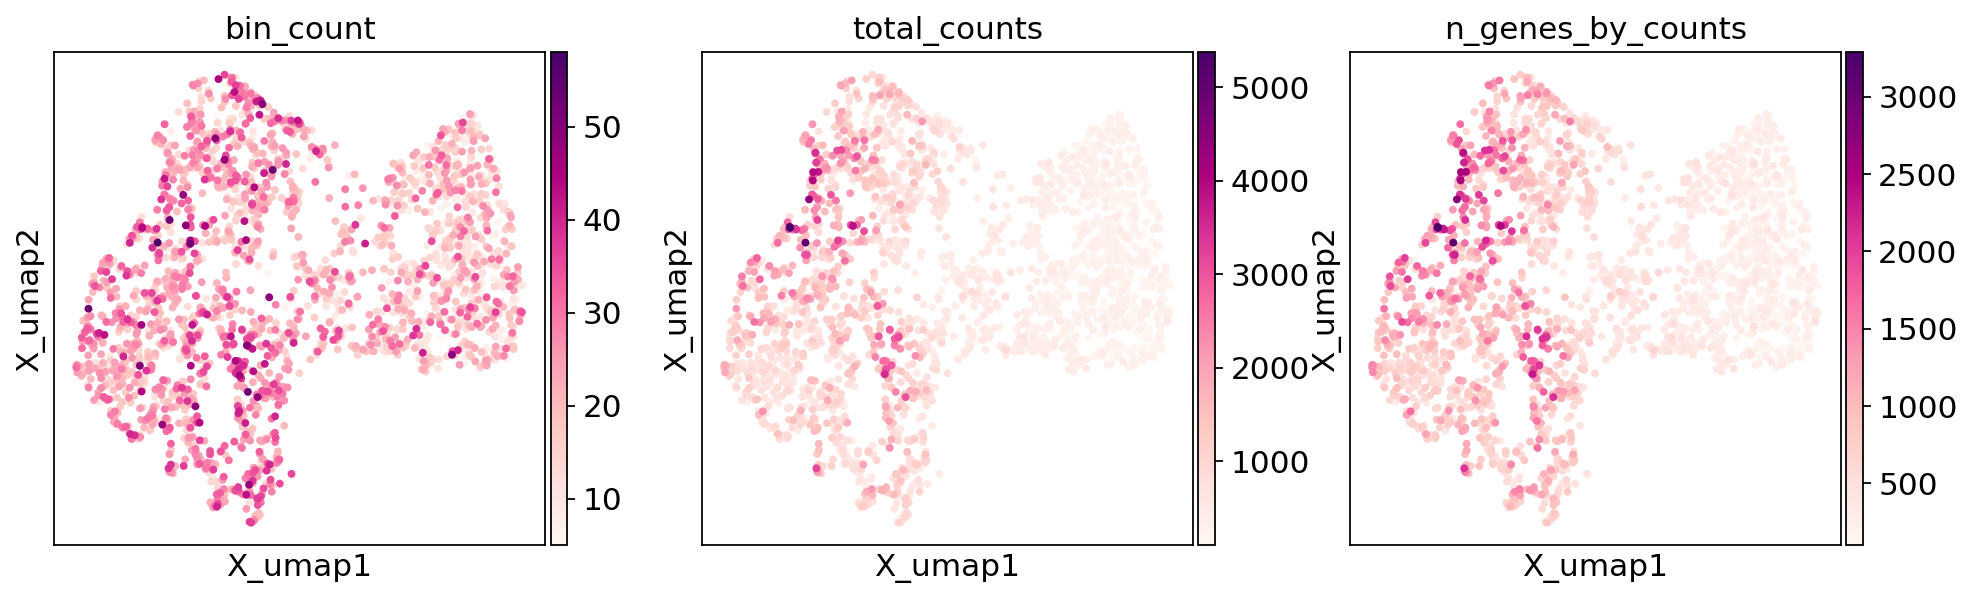

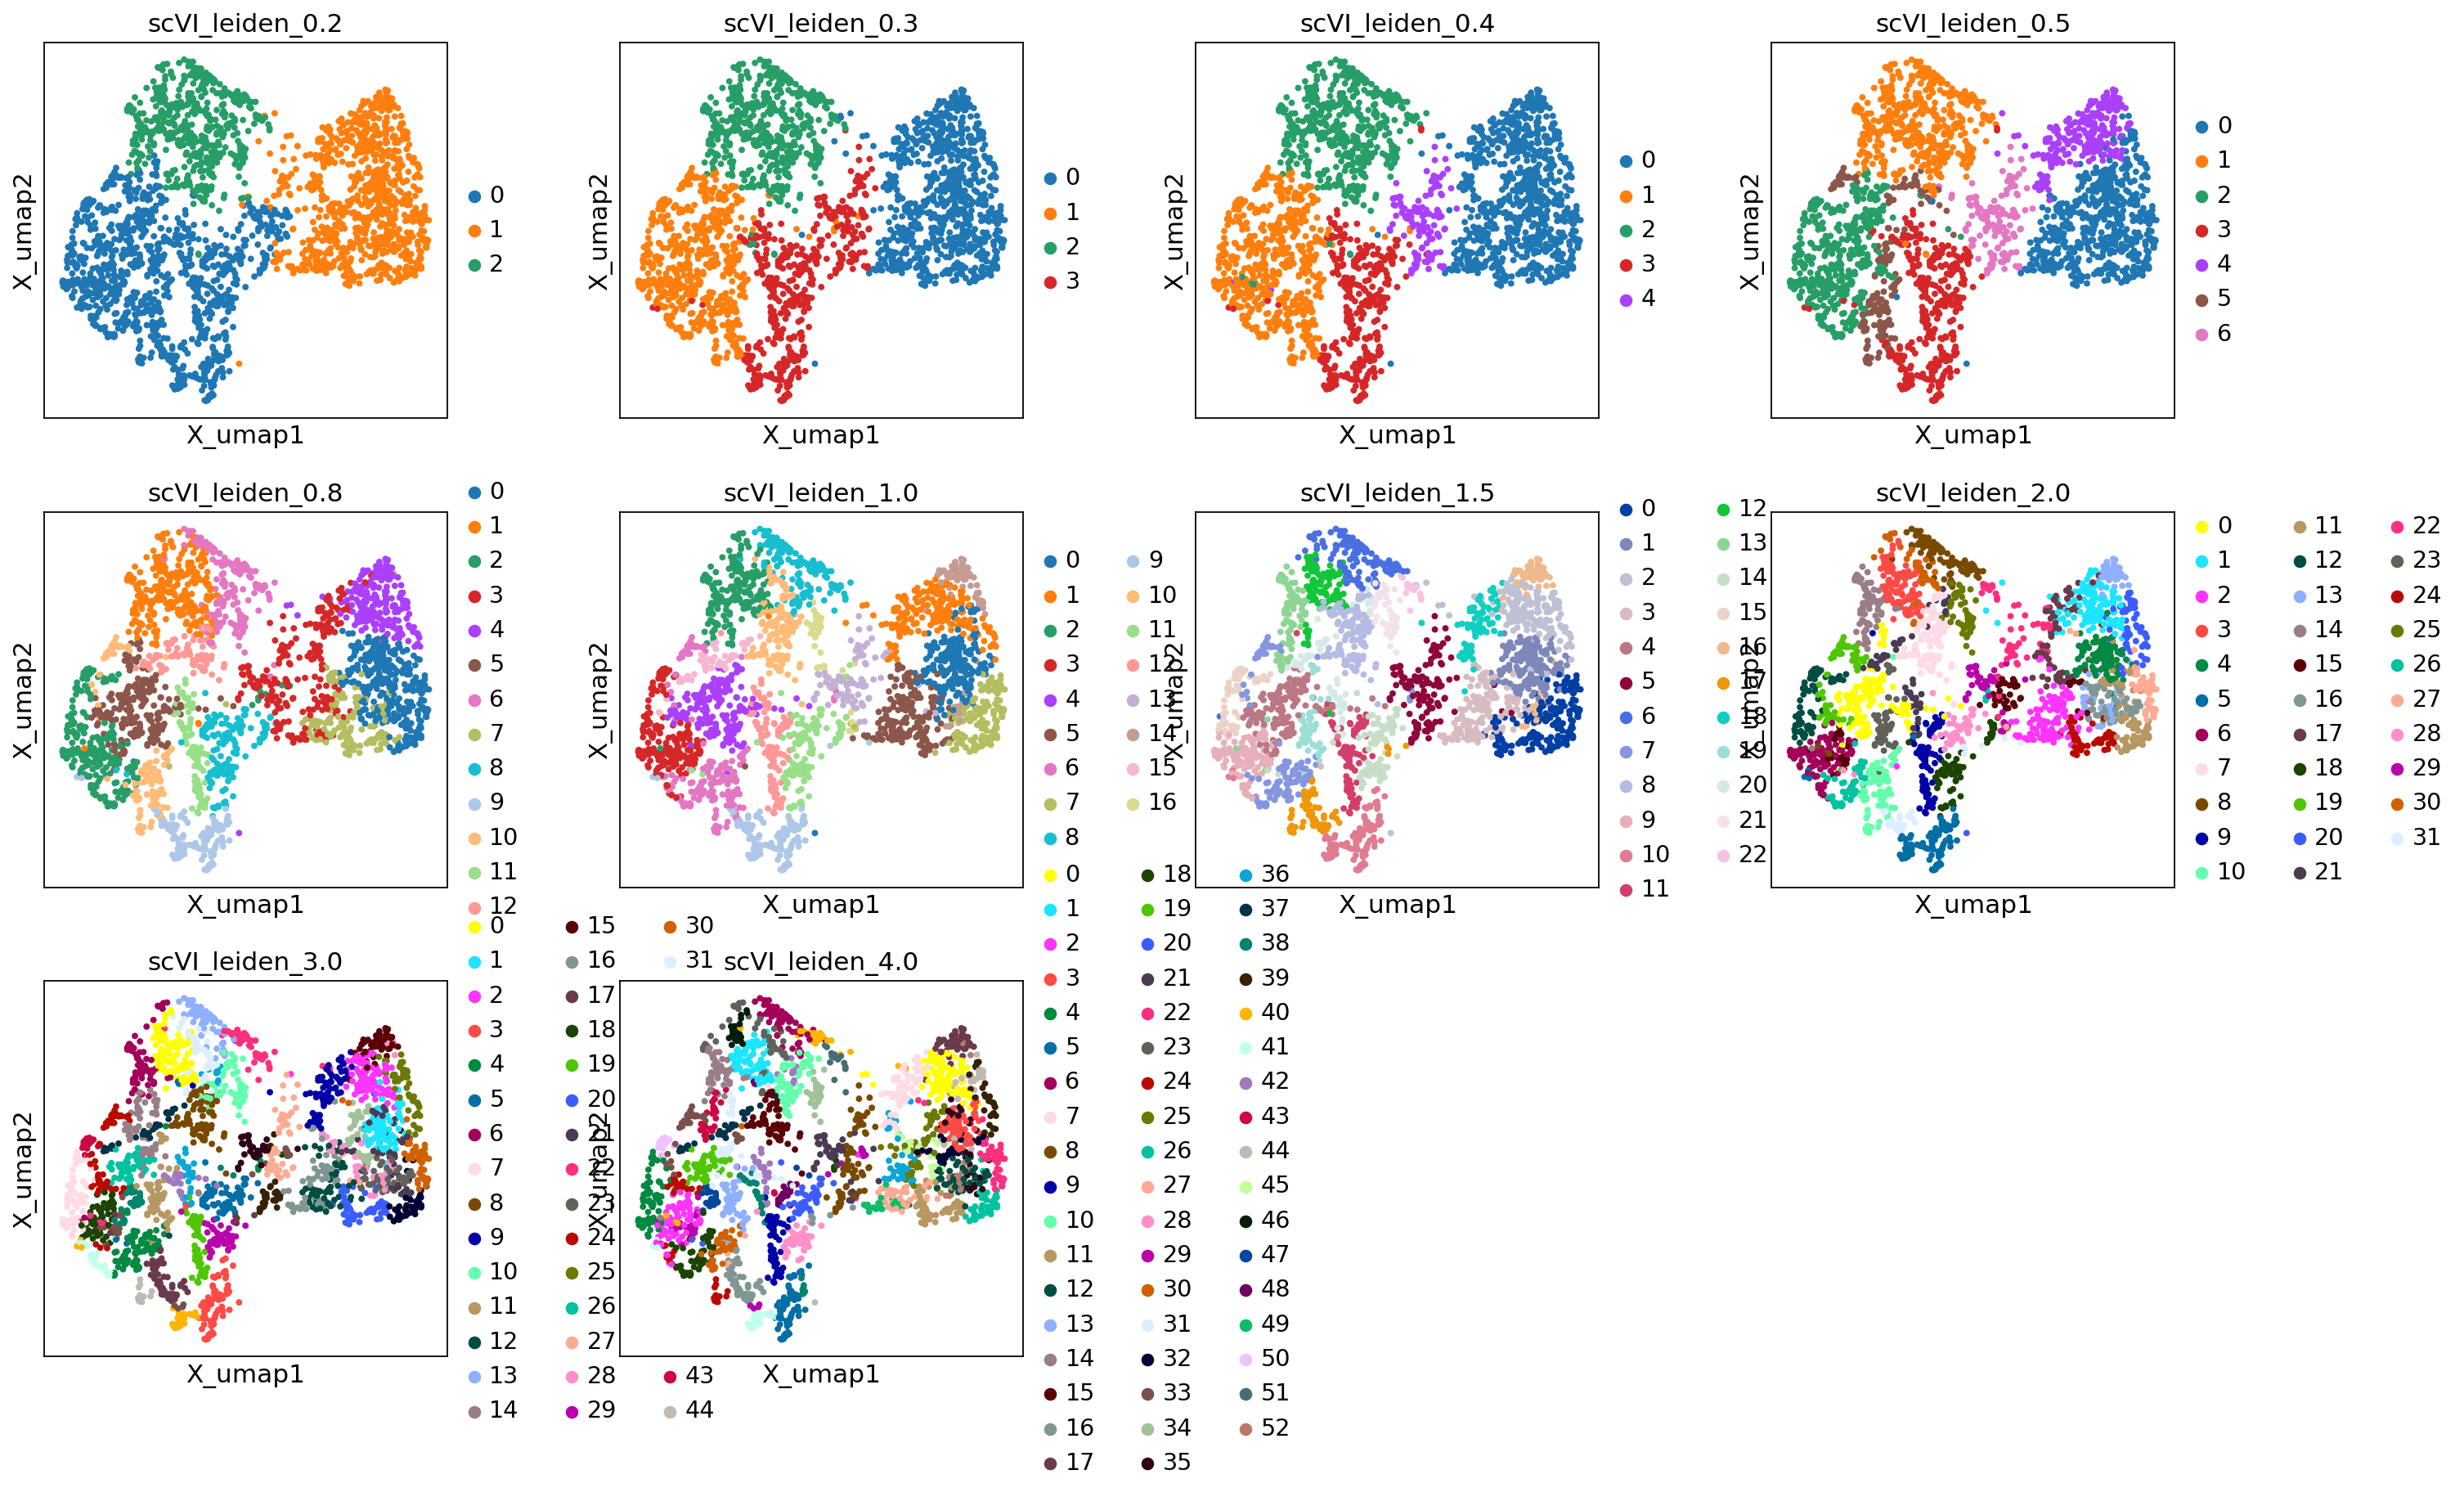

In [13]:
# visualisation with umap
sc.pl.embedding(adata,basis='X_umap',
                color=['bin_count','total_counts','n_genes_by_counts'],
                wspace=0.2,cmap='RdPu',vmax='p100',ncols=5)
# leiden clustering
resolutions_list = [0.2,0.3,0.4,0.5,0.8,1.0,1.5,2.0,3.0,4.0]
sc.pl.embedding(adata,basis='X_umap',
                color=[f'scVI_leiden_{str(resolution)}' for resolution in resolutions_list],
                wspace=0.3)

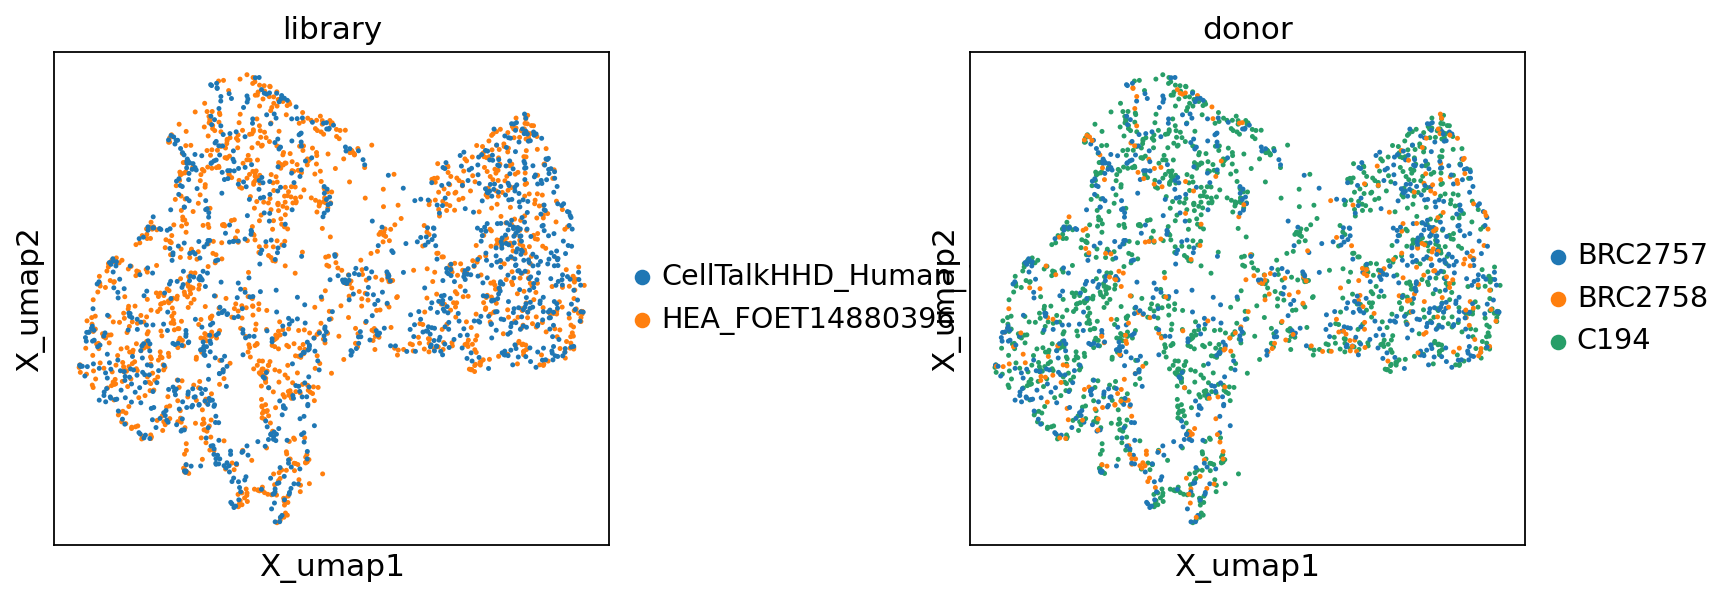

In [14]:
sc.pl.embedding(adata,basis='X_umap',
                color=['library','donor'], 
           size=20, wspace=0.5, ncols=6)

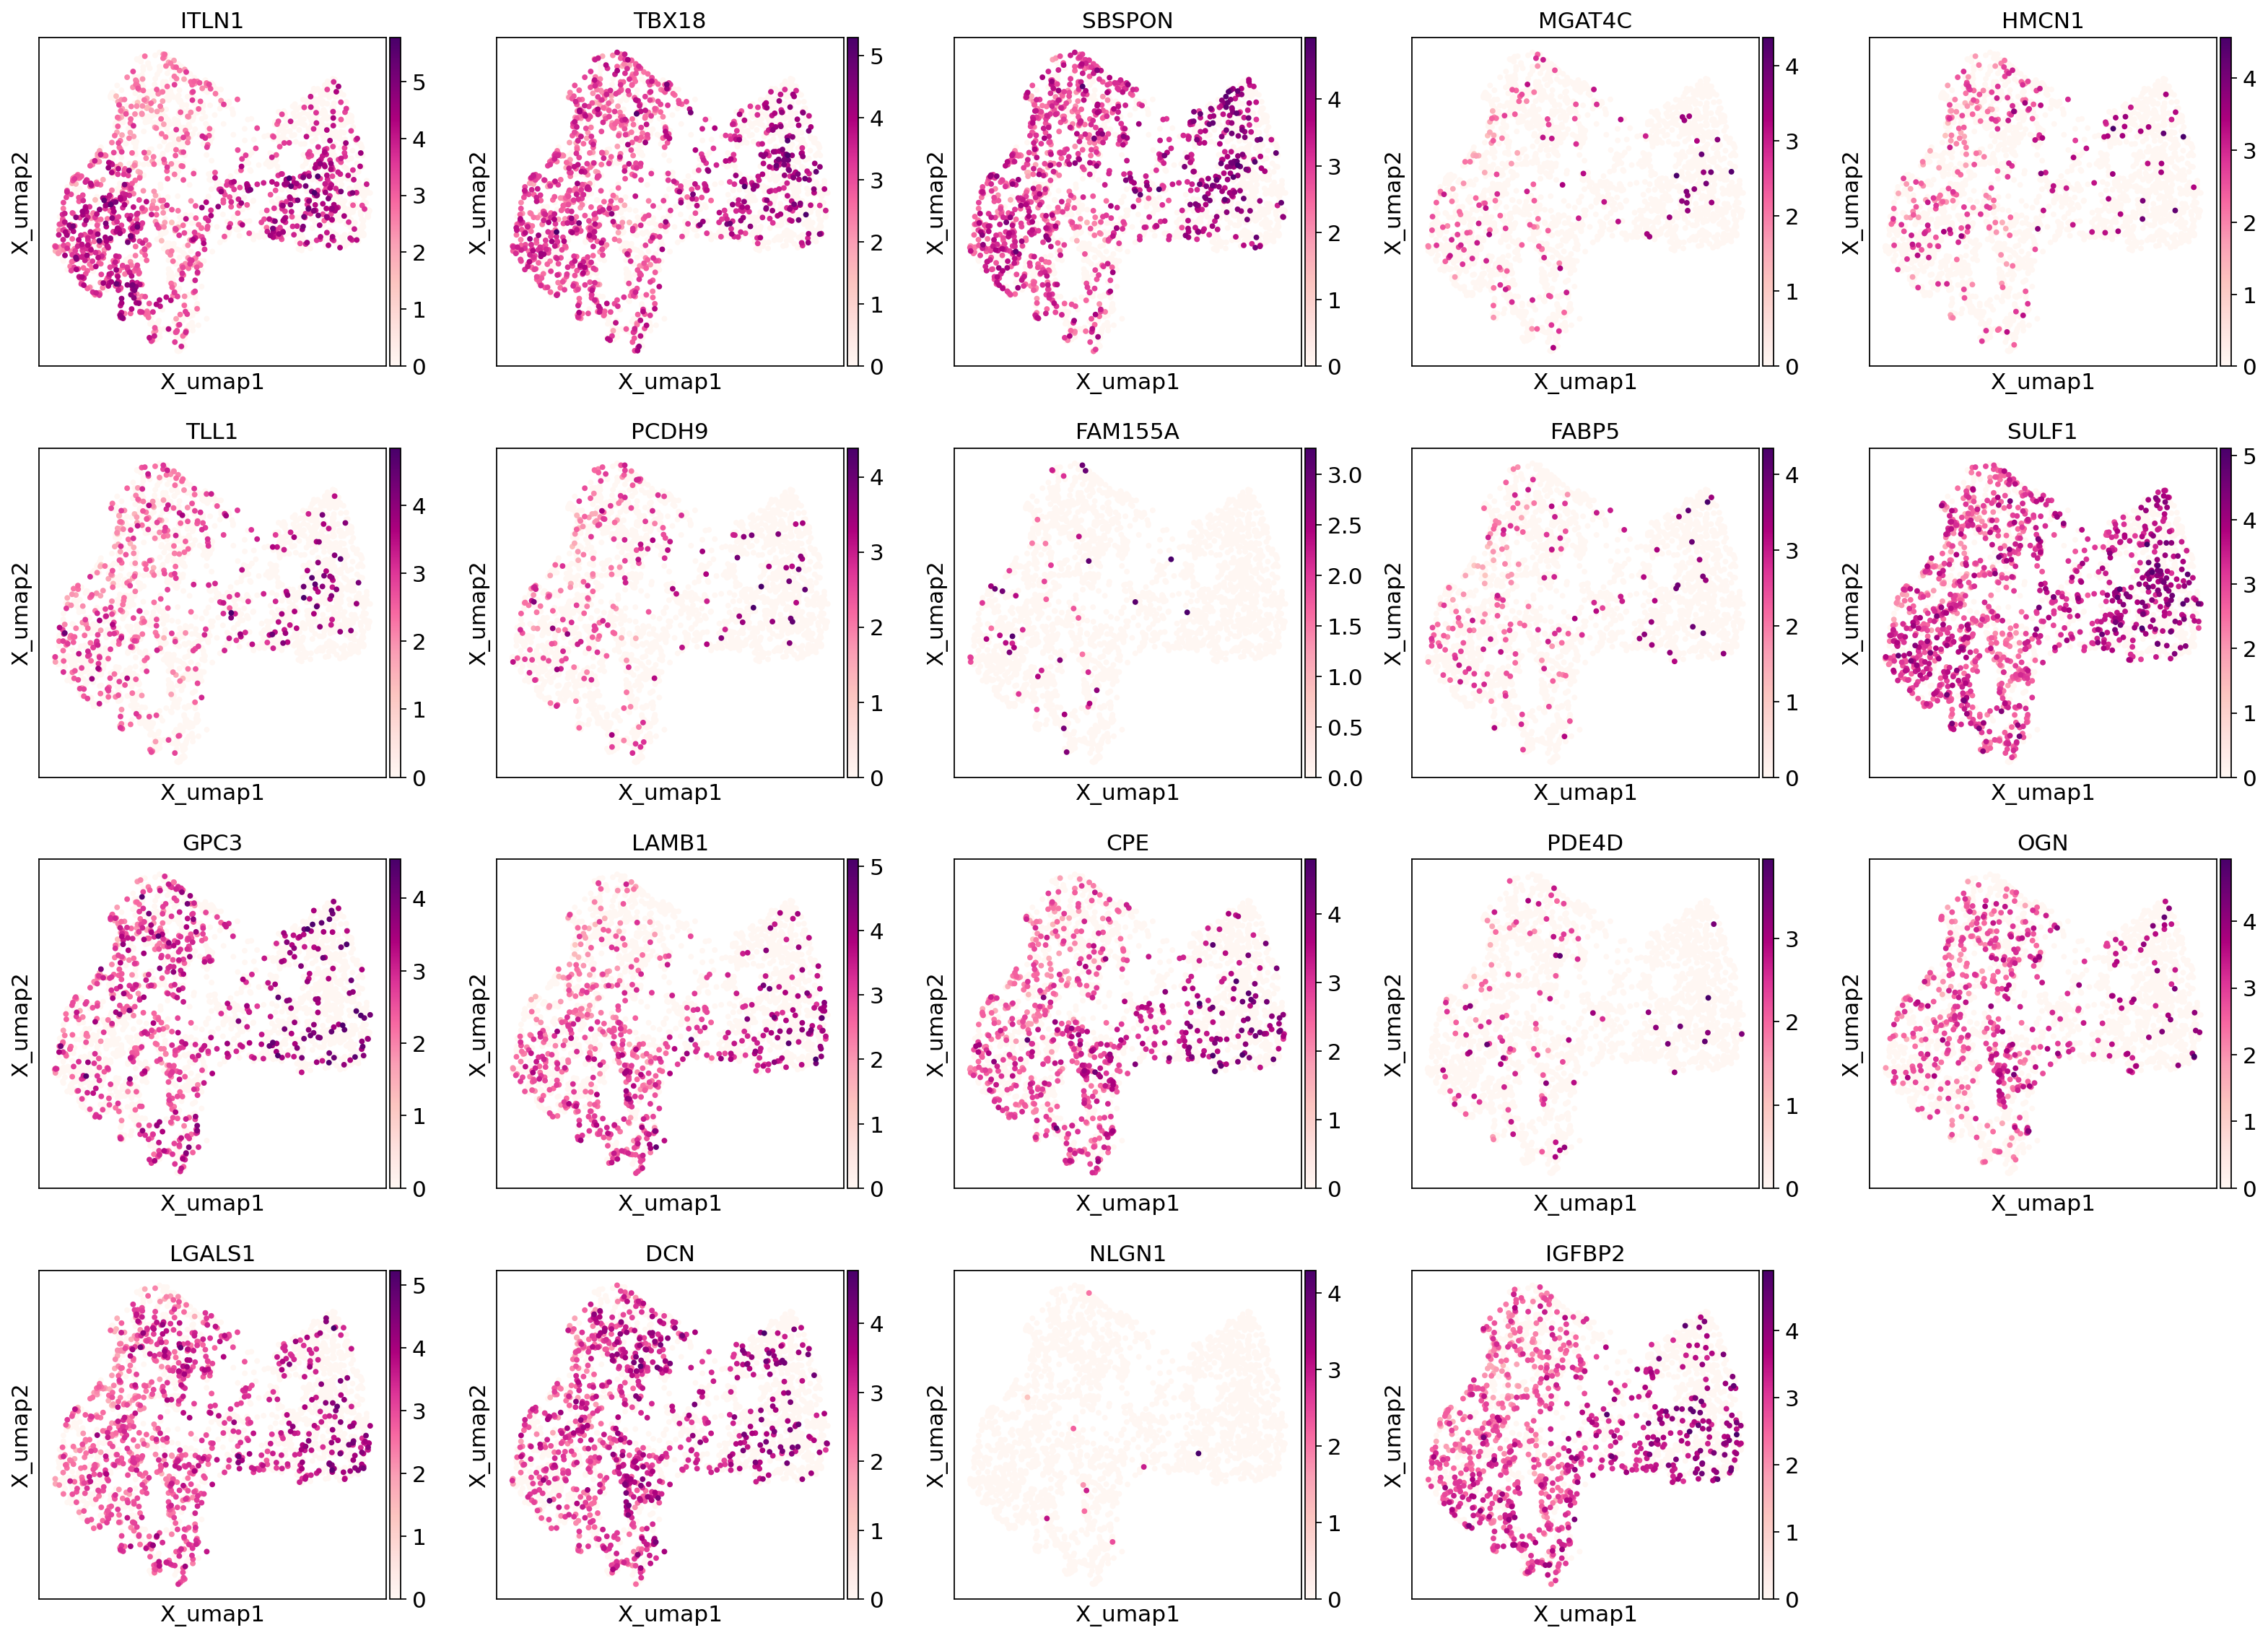

In [16]:
# markers for fine-grained cell types
sc_markers = pd.read_csv(f'/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/VisiumHD/re-seq_mpp0p3/sc_{celltype}_finegrain_markers.csv')
mask1 = sc_markers['group_mean']>1
mask2 = sc_markers['logfoldchanges']>1
sc_markers = sc_markers[mask1&mask2]

markers = {}
n_top = 10
for c in set(sc_markers['group']):
    markers_sub = sc_markers[sc_markers['group']==c]
    markers_sub.sort_values('logfoldchanges',ascending=False)
    markers[c]=list(markers_sub[:n_top]['names'])

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

genes = []
for g in markers.values():
    genes = genes + [x for x in g if (x in adata.var_names)&(x not in genes)]
sc.pl.embedding(adata,basis='X_umap',color=genes,
               ncols=5, wspace=0.2,cmap='RdPu',vmax='p100')

In [19]:
resolution_sel = 0.5

categories: 0, 1, 2, etc.
var_group_labels: CM, Pcell, FB, etc.


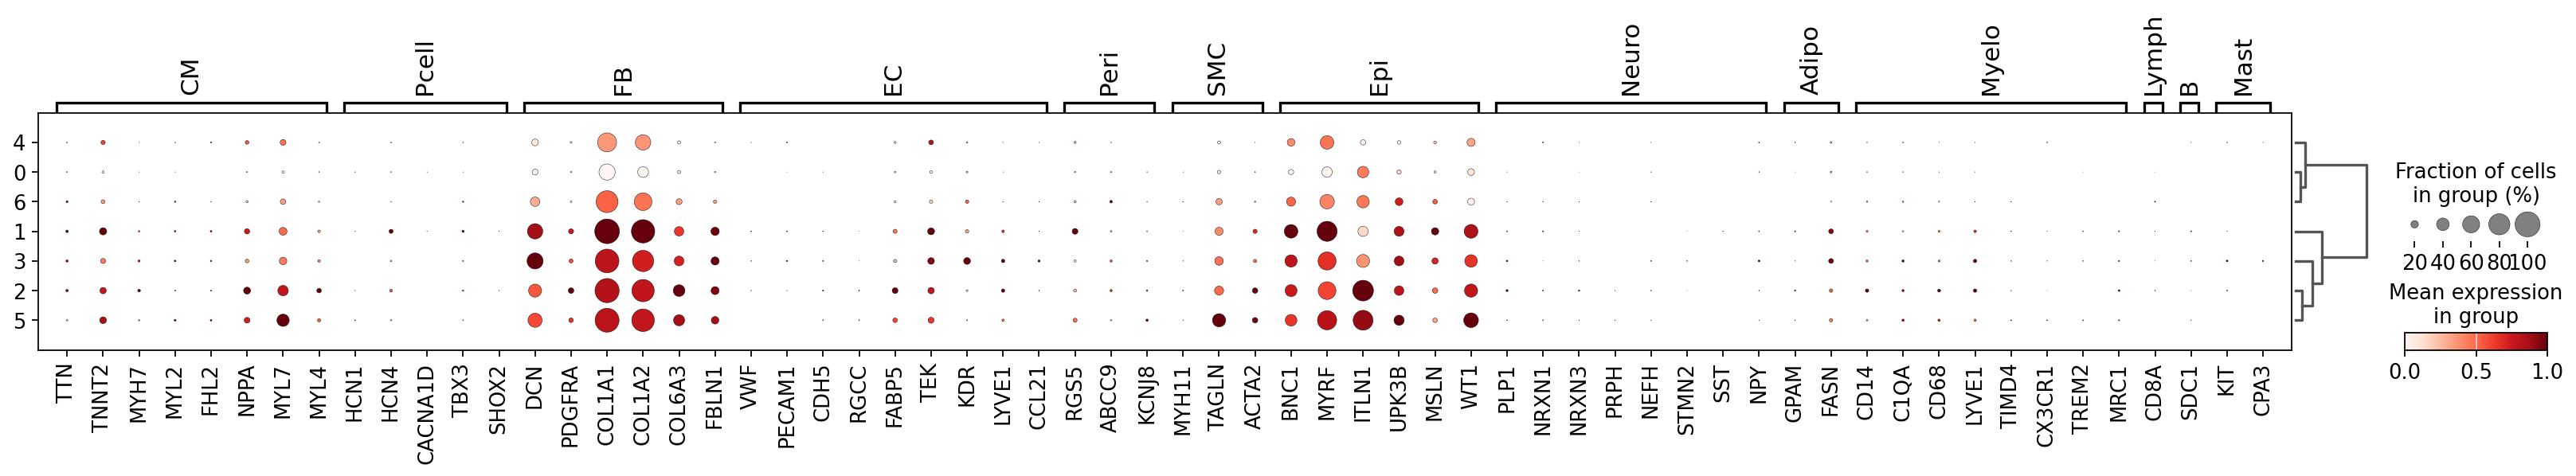

In [20]:
markers = {
    'CM': ['TTN', 'TNNT2','MYH6',
        'MYH7', 'MYL2', 'FHL2', # vCN
            'NPPA', 'MYL7', 'MYL4'], #aCM
    'Pcell':['HCN1','HCN4','CACNA1D','TBX3','SHOX2'],
    'FB': ['DCN', 'GCN', 'PDGFRA','COL1A1','COL1A2','COL6A3','FBLN1'],
    'EC': ['VWF', 'PECAM1', 'CDH5','RGCC', 'FABP5','TEK','KDR','LYVE1','CCL21'],
    'Peri': ['RGS5', 'ABCC9', 'KCNJ8'],
    'SMC': ['MYH11', 'TAGLN', 'ACTA2'],
    'Epi':['BNC1','MYRF','ITLN1','UPK3B','MSLN','WT1'],
    'Neuro': ['PLP1', 'NRXN1', 'NRXN3','PRPH', 'NEFL', 'NEFM', 'NEFH', 'STMN2', 'SST', 'SLC10A4', 'SLC18A3', 'TH', 'NPY'],
    'Adipo': ['GPAM', 'FASN', 'LEP'],
    'Myelo': ['CD14', 'C1QA', 'CD68','LYVE1','TIMD4','CX3CR1','TREM2','MRC1','CCR2','MPO'],
    'Lymph': ['CD3E','CD3D','CD8A','IL7R', 'CD40LG'],
    'B': ['CD19','SDC1','IGHG1','IGHA1'],
    'Mast': ['KIT', 'CPA3'],
}

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

sc.tl.dendrogram(adata, groupby=f'scVI_leiden_{str(resolution_sel)}')
sc.pl.dotplot(adata,
              markers, 
              groupby=f'scVI_leiden_{str(resolution_sel)}',
              dendrogram=True,
              standard_scale="var",
              color_map="Reds",
              swap_axes=False,
             )

categories: 0, 1, 2, etc.
var_group_labels: MesothelialEpicardialCells, EpicardiumDerivedCells


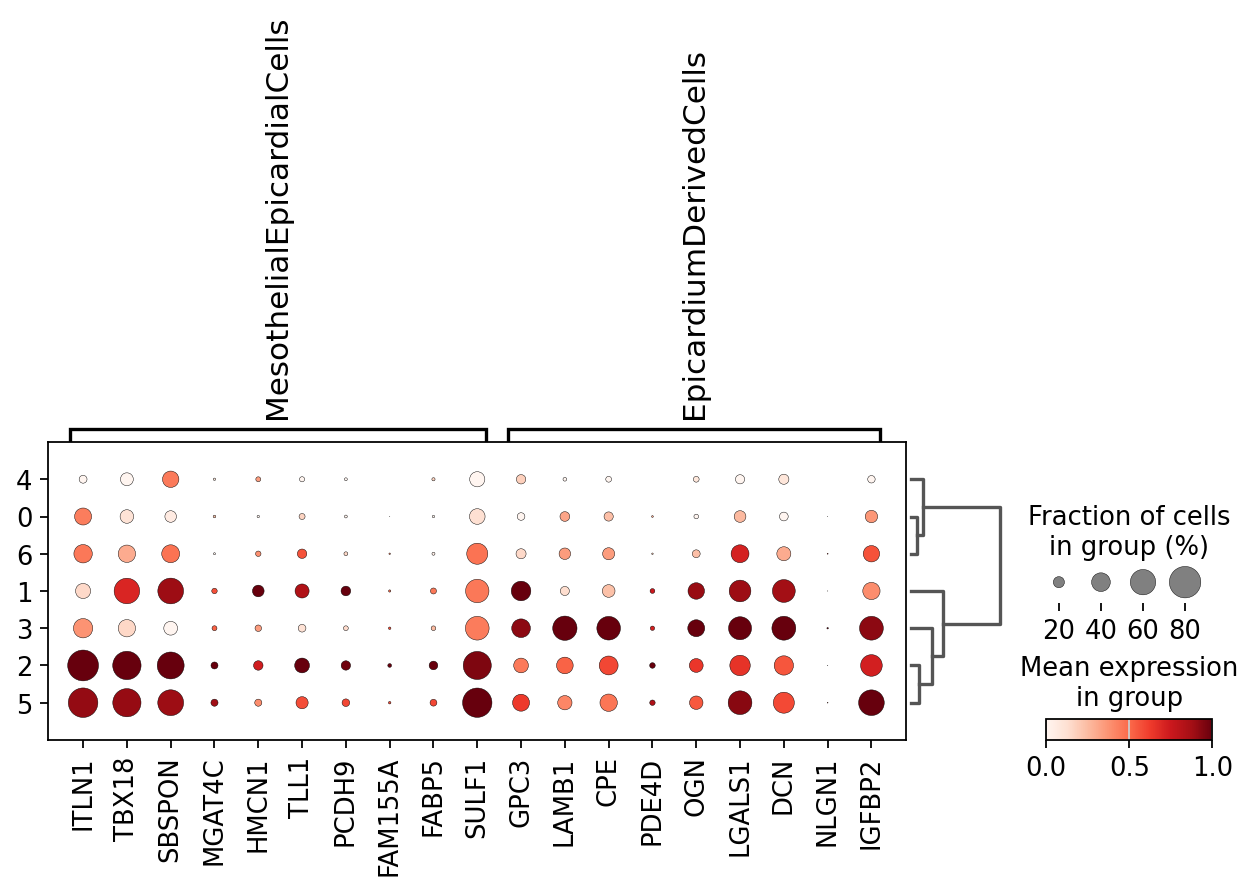

In [27]:
# markers for fine-grained cell types
sc_markers = pd.read_csv(f'/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/VisiumHD/re-seq_mpp0p3/sc_{celltype}_finegrain_markers.csv')
mask1 = sc_markers['group_mean']>1
mask2 = sc_markers['logfoldchanges']>1
sc_markers = sc_markers[mask1&mask2]

markers = {}
n_top = 10
for c in set(sc_markers['group']):
    markers_sub = sc_markers[sc_markers['group']==c]
    markers_sub.sort_values('logfoldchanges',ascending=False)
    markers[c]=list(markers_sub[:n_top]['names'])

for key in markers.keys():
    markers[key]=[x for x in markers[key] if x in adata.var_names]

# sc.tl.dendrogram(adata,groupby=f'leiden_{str(resolution_sel)}')
sc.pl.dotplot(adata,
              var_names=markers,
              groupby=f'scVI_leiden_{str(resolution_sel)}',
              standard_scale='var',
              dendrogram=True
             )

[2.58097504 2.58097504 2.58097504 2.58097504 2.58097504]


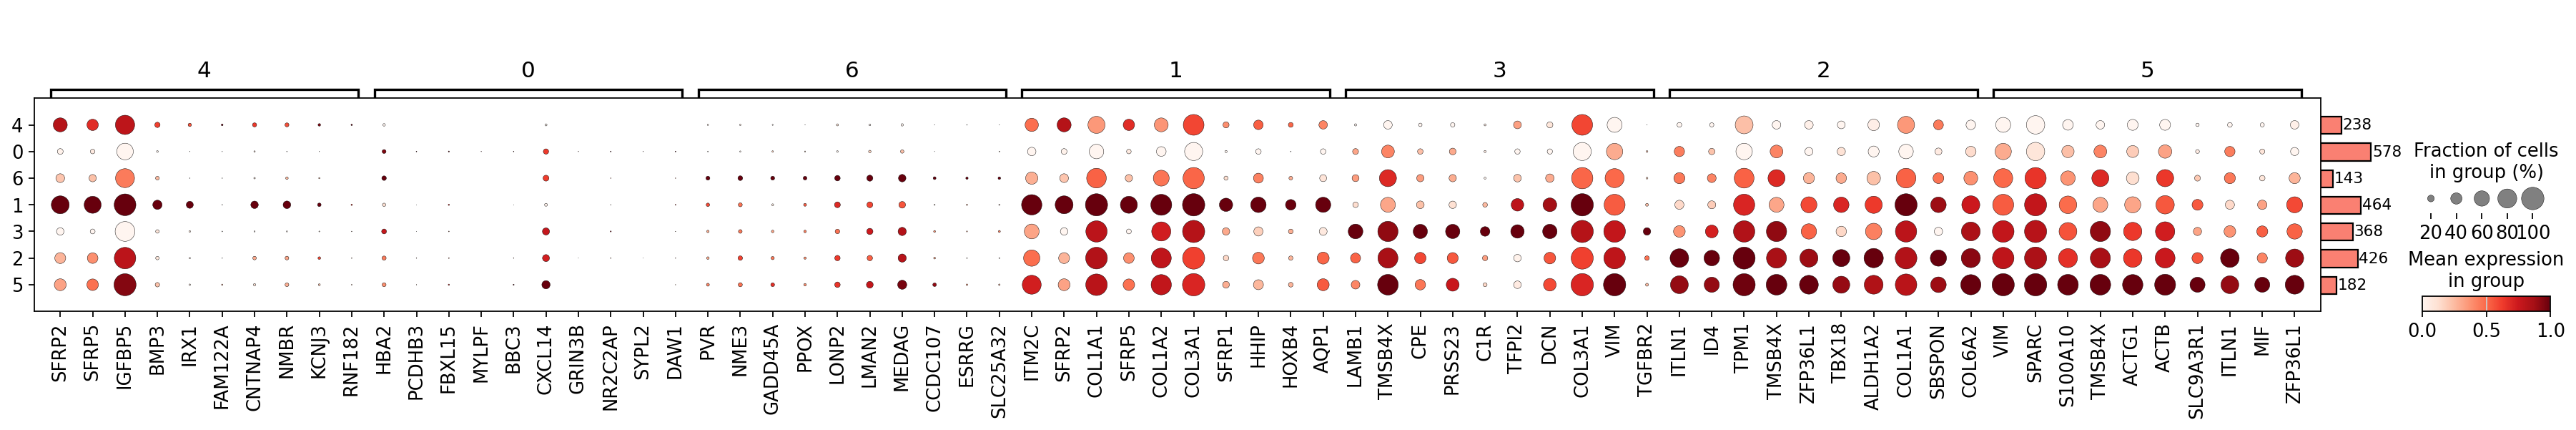

In [23]:
# DEG analysis
print(adata.X.data[:5])
adata.uns['log1p']['base']=None
sc.tl.rank_genes_groups(adata,groupby=f'scVI_leiden_{str(resolution_sel)}')
sc.tl.dendrogram(adata, groupby=f'scVI_leiden_{str(resolution_sel)}')
dp=sc.pl.rank_genes_groups_dotplot(adata, dendrogram=True, standard_scale='var', return_fig=True)
dp.add_totals().show()

# Total counts per group

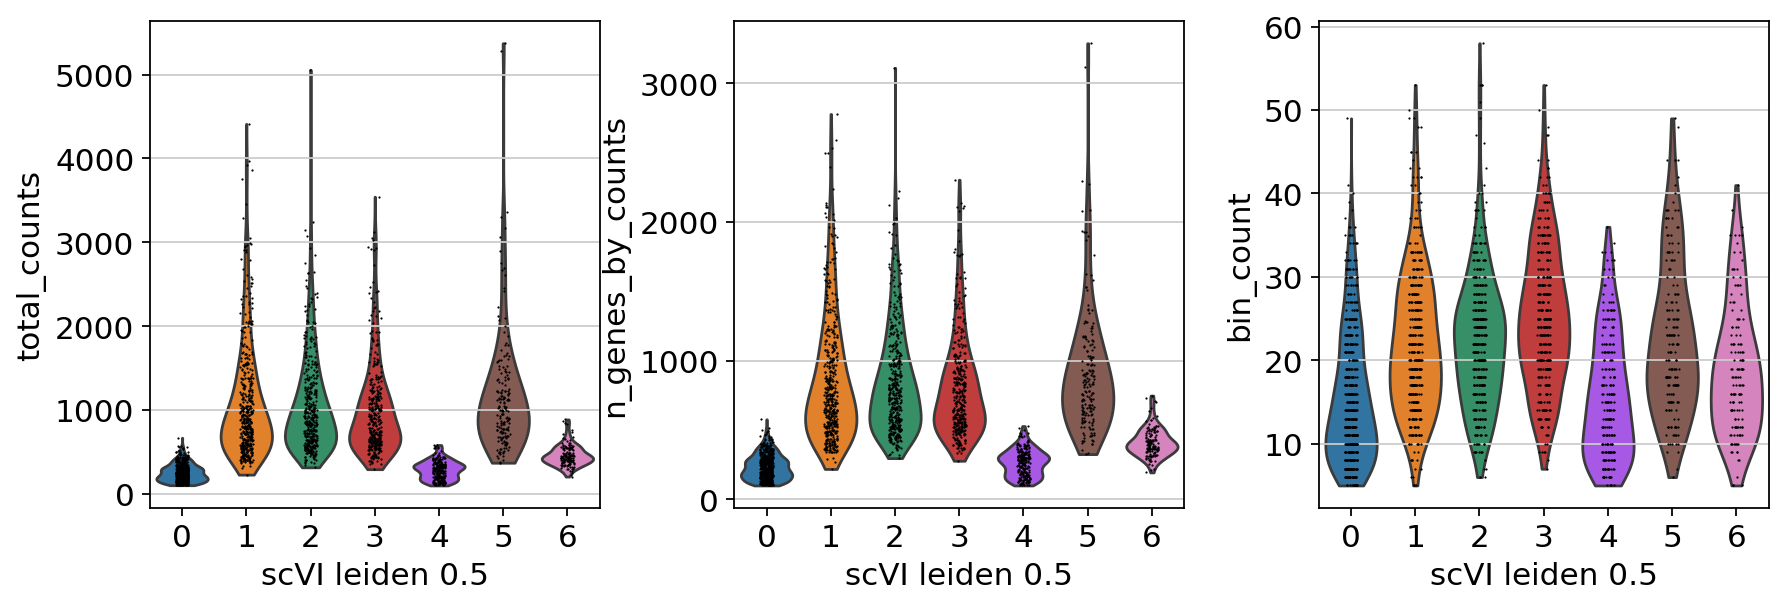

In [24]:
sc.pl.violin(adata,keys=['total_counts','n_genes_by_counts',
                         'bin_count'],groupby=f'scVI_leiden_{str(resolution_sel)}')

# Annotate

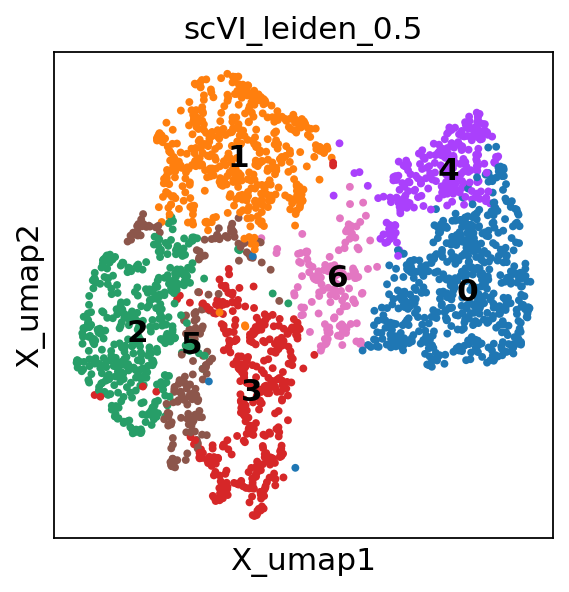

In [25]:
sc.pl.embedding(adata,basis='X_umap',
                color=f'scVI_leiden_{str(resolution_sel)}',
                wspace=0.3, legend_loc='on data')

In [29]:
# annotate
adata.obs['fine_grain'] = adata.obs[f'scVI_leiden_{str(resolution_sel)}'].copy()
adata.obs.replace({'fine_grain':{
    '0':'LowCounts',
    '1':'MesothelialEpicardialCells',
    '2':'MesothelialEpicardialCells',
    '3':'EpicardiumDerivedCells',
    '4':'LowCounts',
    '5':'MesothelialEpicardialCells',
    '6':'LowCounts',
}},inplace=True)
adata.obs['fine_grain'].value_counts()

/tmp/ipykernel_2798910/1037188936.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({'fine_grain':{


fine_grain
MesothelialEpicardialCells    1072
LowCounts                      959
EpicardiumDerivedCells         368
Name: count, dtype: int64

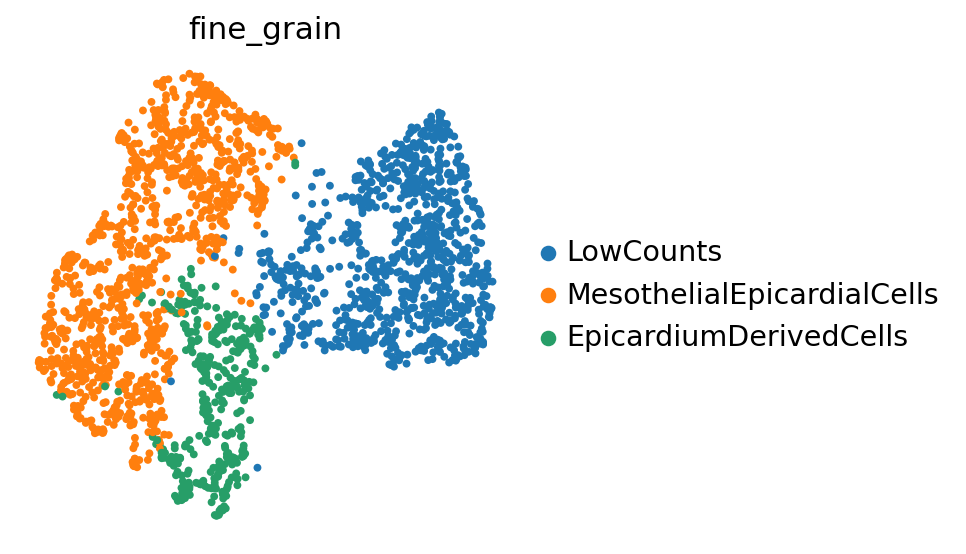

In [30]:
sc.pl.embedding(adata,basis='X_umap',
                color='fine_grain',
                frameon=False,
                wspace=0.3)

categories: LowCounts, MesothelialEpicardialCells, EpicardiumDerivedCells
var_group_labels: MesothelialEpicardialCells, EpicardiumDerivedCells


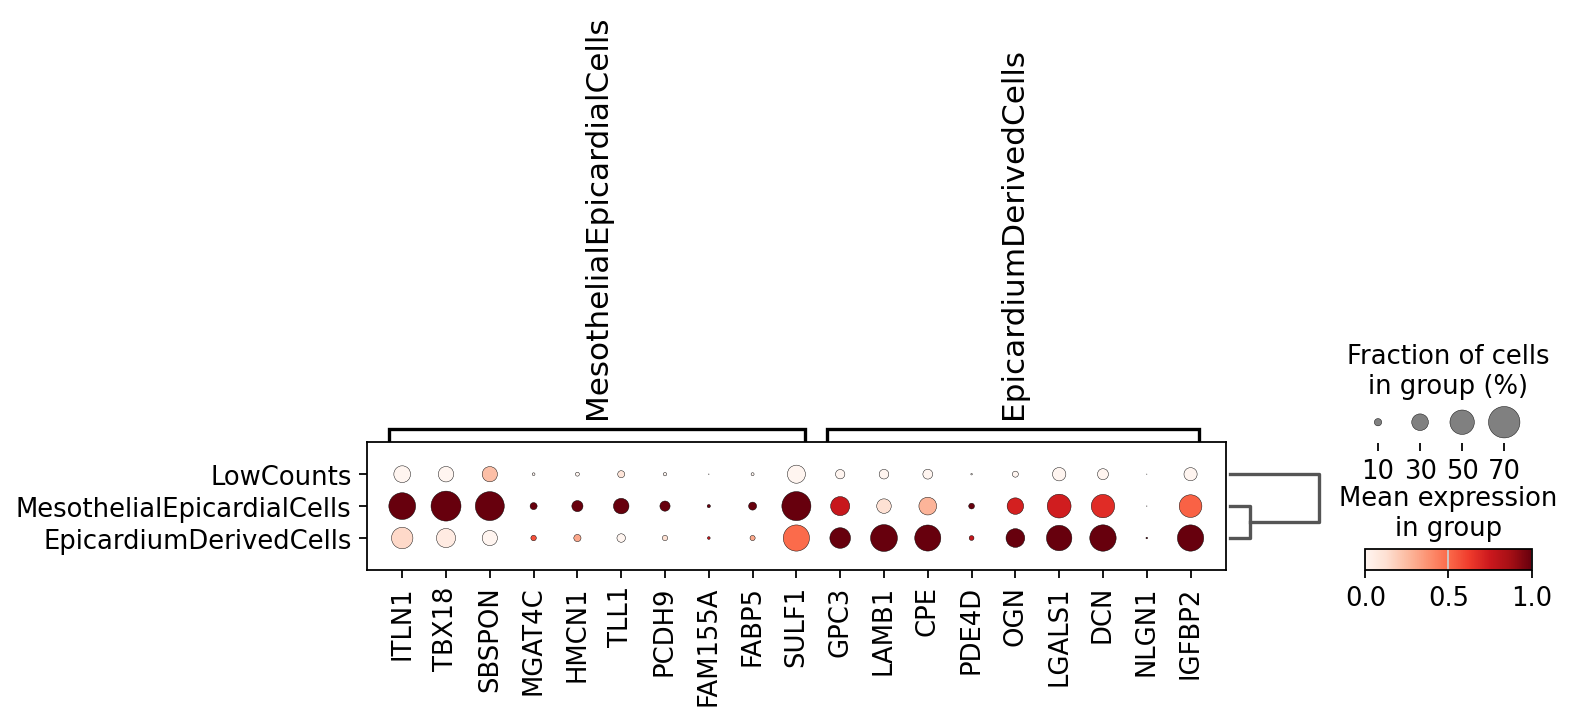

In [31]:
sc.tl.dendrogram(adata,groupby='fine_grain')
sc.pl.dotplot(adata,
              var_names=markers,
              groupby='fine_grain',
              standard_scale='var',
              dendrogram=True
             )

In [32]:
pd.crosstab(adata.obs['donor'],adata.obs['fine_grain']).T

donor,BRC2757,BRC2758,C194
fine_grain,,,
LowCounts,331,153,475
MesothelialEpicardialCells,323,122,627
EpicardiumDerivedCells,105,49,214


# Save

In [33]:
adata.write(f'{data_object_dir}/b2c_cells_{celltype}_lognorm.h5ad')
print(adata.X.data[:5])

[2.58097504 2.58097504 2.58097504 2.58097504 2.58097504]


In [34]:
data_object_dir

'/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/coarse_grain_subsets'